# Automated Program Repair via Prompt Learning: MSR Dataset 

## 0. Environment & Setup

In [1]:
%pip install groq

Note: you may need to restart the kernel to use updated packages.


In [2]:
import shutil

print("gcc:", shutil.which("gcc"))
print("clang:", shutil.which("clang"))
print("cl:", shutil.which("cl"))
print("cppcheck:", shutil.which("cppcheck"))

gcc: C:\mingw64\bin\gcc.EXE
clang: C:\mingw64\bin\clang.EXE
cl: None
cppcheck: C:\mingw64\bin\cppcheck.EXE


In [23]:
import os
from pathlib import Path
import pandas as pd
import json
import time
from string import Template
from datetime import datetime
from textwrap import dedent
from groq import Groq
import re
from difflib import unified_diff
from typing import Optional
from difflib import SequenceMatcher
import shutil
import subprocess
import tempfile
from difflib import SequenceMatcher, unified_diff
from typing import Optional, Dict, Any
import matplotlib.pyplot as plt
import csv
import sys
import seaborn as sns

In [4]:
# Load .env files for API Key
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
# Set path to MSR_Dataset 
BIGVUL_PATH = Path('data/MSR_data_cleaned.csv')   

# Artifacts location
ARTIFACT_DIR = Path('./artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

# Chosen backend = Groq
USE_GROQ = True      

# API Keys 
GROQ_API_KEY = os.getenv('GROQ_API_KEY', '')

if USE_GROQ and not GROQ_API_KEY:
    print('WARNING: GROQ_API_KEY not set. Set env var GROQ_API_KEY to enable Groq backend.')

In [7]:
# Test Groq model
client = Groq(api_key=GROQ_API_KEY)

resp = client.chat.completions.create(
    model="llama-3.3-70b-versatile",
    messages=[
        {"role": "user", "content": "Say hello in one word."}
    ],
    temperature=0.2,
)

print(resp.choices[0].message.content)

Hello.


## 1. Load BigVul Dataset

BigVul Rows Contents:
- **func_before**: The function before the vulnerability is fixed (if "vul" = "1", then this is the vulnerable function).
- **func_after**: The function after the vulnerability is fixed.
- **lines_before**: The modified lines in the function before the vulnerability was fixed.
- **lines_after**: The modified lines in the function after the vulnerabilitiy is fixed.
- **vul**: "1" menas vulnerable function and "0" means non-vulnerable function.
- **vul_func_with_fix**: The code comments showing how the vulnerability was fixed.


In [31]:
import pandas as pd
import csv
import sys

max_int = sys.maxsize
while True:
    try:
        csv.field_size_limit(max_int)
        break
    except OverflowError:
        max_int = int(max_int / 10)

needed_cols = [
    'Unnamed: 0',
    'vul',
    'CVE ID',
    'CWE ID',
    'func_before',
    'func_after',
    'Summary'
]

if BIGVUL_PATH.exists():
    if BIGVUL_PATH.suffix.lower() == '.csv':
        chunks = []

        for chunk in pd.read_csv(
            BIGVUL_PATH,
            engine="python",
            chunksize=5000,
            usecols=lambda c: c in needed_cols
        ):
            chunk = chunk[chunk['vul'] == 1]
            chunks.append(chunk)

        df = pd.concat(chunks, ignore_index=True)

    elif BIGVUL_PATH.suffix.lower() in ('.jsonl', '.jl'):
        df = pd.read_json(BIGVUL_PATH, lines=True)
        df = df[[c for c in needed_cols if c in df.columns]]
        df = df[df['vul'] == 1].copy()
    else:
        raise ValueError(f'Unsupported file type: {BIGVUL_PATH.suffix}')
else:
    print('NOTE: BIGVUL_PATH not found.')

print('Loaded vulnerable rows:', len(df))
print("Columns:")
print(df.columns)
print("Dataset Peek:")
print(df.head(5))

print(df['vul'].value_counts())
display(df.head(5))

Loaded vulnerable rows: 10900
Columns:
Index(['Unnamed: 0', 'CVE ID', 'CWE ID', 'Summary', 'func_after',
       'func_before', 'vul'],
      dtype='object')
Dataset Peek:
   Unnamed: 0         CVE ID   CWE ID  \
0      177736  CVE-2015-8467  CWE-264   
1      177737  CVE-2015-8382  CWE-119   
2      177738  CVE-2013-6712  CWE-119   
3      177739  CVE-2013-6449  CWE-310   
4      177740  CVE-2013-6420  CWE-119   

                                             Summary  \
0  The samldb_check_user_account_control_acl func...   
1  The match function in pcre_exec.c in PCRE befo...   
2  The scan function in ext/date/lib/parse_iso_in...   
3  The ssl_get_algorithm2 function in ssl/s3_lib....   
4  The asn1_time_to_time_t function in ext/openss...   

                                          func_after  \
0  static int samldb_check_user_account_control_a...   
1  PHPAPI void php_pcre_match_impl(pcre_cache_ent...   
2  static int scan(Scanner *s)\n{\n\tuchar *curso...   
3   long ssl_get_algo

,Unnamed: 0,CVE ID,CWE ID,Summary,func_after,func_before,vul
0,177736,CVE-2015-8467,CWE-264,The samldb_check_user_account_control_acl func...,static int samldb_check_user_account_control_a...,static int samldb_check_user_account_control_a...,1
1,177737,CVE-2015-8382,CWE-119,The match function in pcre_exec.c in PCRE befo...,PHPAPI void php_pcre_match_impl(pcre_cache_ent...,PHPAPI void php_pcre_match_impl(pcre_cache_ent...,1
2,177738,CVE-2013-6712,CWE-119,The scan function in ext/date/lib/parse_iso_in...,static int scan(Scanner *s)\n{\n\tuchar *curso...,static int scan(Scanner *s)\n{\n\tuchar *curso...,1
3,177739,CVE-2013-6449,CWE-310,The ssl_get_algorithm2 function in ssl/s3_lib....,long ssl_get_algorithm2(SSL *s)\n {\n ...,long ssl_get_algorithm2(SSL *s)\n {\n ...,1
4,177740,CVE-2013-6420,CWE-119,The asn1_time_to_time_t function in ext/openss...,static time_t asn1_time_to_time_t(ASN1_UTCTIME...,static time_t asn1_time_to_time_t(ASN1_UTCTIME...,1


## Data Cleaning and Sampling:
- Filter to C only (lang == "C").
- Choose top CWE categories.
- Select top 5 CVE IDs from chosen CWE categories.

In [33]:
print(df.columns)

Index(['Unnamed: 0', 'CVE ID', 'CWE ID', 'Summary', 'func_after',
       'func_before', 'vul'],
      dtype='object')


In [35]:
# Filter vulnerable rows
df_vul = df[df['vul'] == 1].copy()

CWE_COL = 'CWE ID'   
CVE_COL = 'CVE ID'
TOP_CWES = 5
TOP_CVES_PER_CWE = 3
SAMPLES_PER_CVE = 20
RANDOM_STATE = 42

if CWE_COL not in df_vul.columns or CVE_COL not in df_vul.columns:
    raise ValueError(f"Required columns not found. Have columns: {list(df_vul.columns)}")

# Remove missing CWE/CVE rows
df_vul = df_vul.dropna(subset=[CWE_COL, CVE_COL]).copy()

# Identify top CWE categories
top_cwes = (
    df_vul[CWE_COL]
    .value_counts()
    .head(TOP_CWES)
    .index
)

df_top_cwes = df_vul[df_vul[CWE_COL].isin(top_cwes)].copy()

# Select top 5 CVE per chosen CWE category
selected_parts = []

for cwe in top_cwes:
    df_cwe = df_top_cwes[df_top_cwes[CWE_COL] == cwe].copy()

    top_cves_in_cwe = (
        df_cwe[CVE_COL]
        .value_counts()
        .head(TOP_CVES_PER_CWE)
        .index
    )

    df_cwe_top_cves = df_cwe[df_cwe[CVE_COL].isin(top_cves_in_cwe)].copy()

    for cve in top_cves_in_cwe:
        df_cve = df_cwe_top_cves[df_cwe_top_cves[CVE_COL] == cve].copy()

        n = min(SAMPLES_PER_CVE, len(df_cve))
        df_sampled = df_cve.sample(n=n, random_state=RANDOM_STATE)

        selected_parts.append(df_sampled)

# Final subset
df_subset = pd.concat(selected_parts, ignore_index=True)
df_subset = df_subset.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

print("Final subset size:", len(df_subset))
print("\nCounts by CWE:")
print(df_subset[CWE_COL].value_counts())

print("\nCounts by (CWE, CVE):")
print(df_subset.groupby([CWE_COL, CVE_COL]).size())

display(df_subset.head(5))

Final subset size: 293

Counts by CWE:
CWE ID
CWE-20     60
CWE-119    60
CWE-399    60
CWE-264    57
CWE-125    56
Name: count, dtype: int64

Counts by (CWE, CVE):
CWE ID   CVE ID        
CWE-119  CVE-2016-10066    20
         CVE-2016-1621     20
         CVE-2016-4303     20
CWE-125  CVE-2016-5093     20
         CVE-2017-5077     16
         CVE-2018-16427    20
CWE-20   CVE-2011-2350     20
         CVE-2016-2464     20
         CVE-2018-6111     20
CWE-264  CVE-2010-1172     20
         CVE-2011-3084     20
         CVE-2014-3647     17
CWE-399  CVE-2011-2804     20
         CVE-2011-2918     20
         CVE-2012-2888     20
dtype: int64


,Unnamed: 0,CVE ID,CWE ID,Summary,func_after,func_before,vul
0,184033,CVE-2011-2350,CWE-20,The HTML parser in Google Chrome before 12.0.7...,EncodedJSValue JSC_HOST_CALL jsTestMediaQueryL...,EncodedJSValue JSC_HOST_CALL jsTestMediaQueryL...,1
1,184706,CVE-2011-3084,CWE-264,Google Chrome before 19.0.1084.46 does not use...,virtual void SetUp() {\n url_util::AddSt...,virtual void SetUp() {\n url_util::AddSt...,1
2,180442,CVE-2016-4303,CWE-119,The parse_string function in cjson.c in the cJ...,cJSON *cJSON_CreateBool( int b )\n,cJSON *cJSON_CreateBool( int b )\n{\n\tcJSON *...,1
3,184315,CVE-2012-2888,CWE-399,Use-after-free vulnerability in Google Chrome ...,const PPB_NaCl_Private* GetNaclInterface() {\n,const PPB_NaCl_Private* GetNaclInterface() {\n...,1
4,178944,CVE-2011-2918,CWE-399,The Performance Events subsystem in the Linux ...,static void alpha_perf_event_irq_handler(unsig...,static void alpha_perf_event_irq_handler(unsig...,1


In [37]:
df_subset['CWE ID'].value_counts()

CWE ID
CWE-20     60
CWE-119    60
CWE-399    60
CWE-264    57
CWE-125    56
Name: count, dtype: int64

In [39]:
df_subset['CWE ID'].nunique()

5

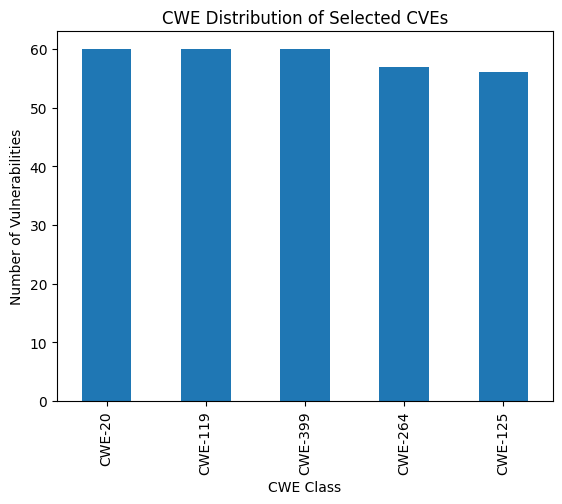

In [41]:
df_subset['CWE ID'].value_counts().plot(kind='bar')
plt.title("CWE Distribution of Selected CVEs")
plt.xlabel("CWE Class")
plt.ylabel("Number of Vulnerabilities")
plt.show()

In [43]:
df_subset[['CVE ID', 'CWE ID']].drop_duplicates()

,CVE ID,CWE ID
0,CVE-2011-2350,CWE-20
1,CVE-2011-3084,CWE-264
2,CVE-2016-4303,CWE-119
3,CVE-2012-2888,CWE-399
4,CVE-2011-2918,CWE-399
5,CVE-2011-2804,CWE-399
6,CVE-2017-5077,CWE-125
7,CVE-2018-6111,CWE-20
8,CVE-2016-1621,CWE-119
12,CVE-2016-10066,CWE-119


## 2. Prompt Template (Repair Instruction)

Objective: To keep prompts **specific**, **constrained**, and **reproducible**, and provide the vulnerable function and constraints.

**Design notes:**
- Ask for **minimal** patch, not a full rewrite.
- Name the **CWE** if known.
- Request **only the fixed function** in output.
- Optionally include **project/file/function** context if it helps.

In [46]:
REPAIR_TEMPLATE = Template(r"""
You are a C security reviewer. Fix the following function to remove the vulnerability.
- Vulnerability CVE ID: $cve
- Vulnerability description: $desc

Instructions:
- Keep behavior identical except for the fix.
- Make the **minimal necessary changes**.
- Return **only the fixed function code** (no explanations, no comments from you).

<function>
$func
</function>
""".strip())

def build_repair_prompt(vuln_func: str, cve: str = 'Unknown', desc: str | None = None):
    prompt = REPAIR_TEMPLATE.substitute(
        cve=cve,
        desc = desc or "No description provided.",
        func=vuln_func.strip()
    )
    return prompt

# Smoke test on first row
row0 = df_subset.iloc[0]
test_prompt = build_repair_prompt(row0.get('func_before',''), row0.get('CVE ID','Unknown'))
print(test_prompt[:600], '...\n\n--- PROMPT LENGTH:', len(test_prompt))
with open(ARTIFACT_DIR / f'prompt_preview_{datetime.now().strftime("%Y%m%d_%H%M%S")}.txt', 'w', encoding='utf-8') as f:
    f.write(test_prompt)

You are a C security reviewer. Fix the following function to remove the vulnerability.
- Vulnerability CVE ID: CVE-2011-2350
- Vulnerability description: No description provided.
- Keep behavior identical except for the fix.
- Make the **minimal necessary changes**.
- Return **only the fixed function code** (no explanations, no comments from you).

<function>
EncodedJSValue JSC_HOST_CALL jsTestMediaQueryListListenerPrototypeFunctionMethod(ExecState* exec)
{
    JSValue thisValue = exec->hostThisValue();
    if (!thisValue.inherits(&JSTestMediaQueryListListener::s_info))
        return throwVMT ...

--- PROMPT LENGTH: 1354


## 3. LLM Backend Setup

In [74]:
def run_groq(prompt: str, model: str = "llama-3.3-70b-versatile") -> Optional[str]:

    MAX_PROMPT_CHARS = 20000
    
    if not GROQ_API_KEY:
        print("Groq backend disabled or missing API key.")
        return None

    if len(prompt) > MAX_PROMPT_CHARS:
        print("Prompt too large, truncating...")
        prompt = prompt[:MAX_PROMPT_CHARS]
    
    try:
        from groq import Groq

        client = Groq(api_key=GROQ_API_KEY)

        resp = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a careful C security patching assistant."},
                {"role": "user", "content": prompt},
            ],
            temperature=0.2,
        )

        return resp.choices[0].message.content

    except Exception as e:
        print("Groq error:", e)
        return None


## 4. Inference Loop (Small Batch)

Takes a small subset of rows, builds prompts, calls the chosen backend, and saves outputs to `./artifacts`.

In [77]:
def run_repair_on_rows(
    rows,
    backend='groq',
    limit=None,
    include_desc=False,
    save_path=None,
    save_every=10,
    sleep_sec=0.2,
    resume=True
):
    results = []

    if limit is None:
        limit = len(rows)

    done_ids = set()
    if save_path is not None and resume and Path(save_path).exists():
        with open(save_path, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    done_ids.add(rec["id"])
                except Exception:
                    pass
        print(f"Resuming: found {len(done_ids)} completed rows in {save_path}")

    processed_since_flush = 0

    for i, (_, row) in enumerate(rows.iterrows()):
        if i >= limit:
            break

        rid = int(row.get("Unnamed: 0", i))

        if rid in done_ids:
            continue

        vuln = row.get('func_before', '')
        cve  = row.get('CVE ID', 'Unknown')
        desc = row.get("Summary", "") if include_desc else None

        prompt = build_repair_prompt(vuln_func=vuln, cve=cve, desc=desc)

        if backend == 'groq':
            out = run_groq(prompt)
        else:
            raise ValueError('Unknown backend')

        rec = {
            'id': rid,
            'cve_id': cve,
            'desc': desc,
            'prompt': prompt,
            'model_output': out,
            'ground_truth': row.get('func_after', ''),
            'include_desc': include_desc
        }

        results.append(rec)

        if save_path is not None:
            with open(save_path, "a", encoding="utf-8") as f:
                f.write(json.dumps(rec, ensure_ascii=False) + "\n")

        processed_since_flush += 1

        if processed_since_flush % save_every == 0:
            print(f"Saved {processed_since_flush} new rows in this run...")

        time.sleep(sleep_sec)

    print(f"Finished run. New rows processed this run: {len(results)}")
    return results

In [79]:
# Full Run - Batch Size 300

full_rows = df_subset.copy()

# baseline
results_base = run_repair_on_rows(full_rows, backend='groq', limit=len(full_rows), include_desc=False)

# cve + desc
results_desc = run_repair_on_rows(full_rows, backend='groq', limit=len(full_rows), include_desc=True)

# Persist baseline
out_path_base = ARTIFACT_DIR / 'initial_run_results(CVE_only).jsonl'
with open(out_path_base, 'w', encoding='utf-8') as f:
    for r in results_base:
        f.write(json.dumps(r, ensure_ascii=False) + '\n')

print('Saved:', out_path_base)

# Persist CVE+Desc
out_path_desc = ARTIFACT_DIR / 'initial_run_results(CVE+Desc).jsonl'
with open(out_path_desc, 'w', encoding='utf-8') as f:
    for r in results_desc:
        f.write(json.dumps(r, ensure_ascii=False) + '\n')

print('Saved:', out_path_desc)

results_base[:1], results_desc[:1]

Saved 10 new rows in this run...
Saved 20 new rows in this run...
Saved 30 new rows in this run...
Saved 40 new rows in this run...
Saved 50 new rows in this run...
Saved 60 new rows in this run...
Prompt too large, ({len(prompt)} chars), truncating...
Saved 70 new rows in this run...
Saved 80 new rows in this run...
Saved 90 new rows in this run...
Saved 100 new rows in this run...
Saved 110 new rows in this run...
Saved 120 new rows in this run...
Saved 130 new rows in this run...
Saved 140 new rows in this run...
Saved 150 new rows in this run...
Saved 160 new rows in this run...
Saved 170 new rows in this run...
Prompt too large, ({len(prompt)} chars), truncating...
Saved 180 new rows in this run...
Prompt too large, ({len(prompt)} chars), truncating...
Saved 190 new rows in this run...
Saved 200 new rows in this run...
Saved 210 new rows in this run...
Saved 220 new rows in this run...
Saved 230 new rows in this run...
Saved 240 new rows in this run...
Saved 250 new rows in this r

([{'id': 184033,
   'cve_id': 'CVE-2011-2350',
   'desc': None,
   'prompt': 'You are a C security reviewer. Fix the following function to remove the vulnerability.\n- Vulnerability CVE ID: CVE-2011-2350\n- Vulnerability description: No description provided.\n- Keep behavior identical except for the fix.\n- Make the **minimal necessary changes**.\n- Return **only the fixed function code** (no explanations, no comments from you).\n\n<function>\nEncodedJSValue JSC_HOST_CALL jsTestMediaQueryListListenerPrototypeFunctionMethod(ExecState* exec)\n{\n    JSValue thisValue = exec->hostThisValue();\n    if (!thisValue.inherits(&JSTestMediaQueryListListener::s_info))\n        return throwVMTypeError(exec);\n    JSTestMediaQueryListListener* castedThis = jsCast<JSTestMediaQueryListListener*>(asObject(thisValue));\n     ASSERT_GC_OBJECT_INHERITS(castedThis, &JSTestMediaQueryListListener::s_info);\n     TestMediaQueryListListener* impl = static_cast<TestMediaQueryListListener*>(castedThis->impl());

In [83]:
# check if id matches
record = results_base[0]
print(record["id"])
print(df_subset[df_subset["Unnamed: 0"] == record["id"]]["func_before"].iloc[0][:200])

184033
EncodedJSValue JSC_HOST_CALL jsTestMediaQueryListListenerPrototypeFunctionMethod(ExecState* exec)
{
    JSValue thisValue = exec->hostThisValue();
    if (!thisValue.inherits(&JSTestMediaQueryListList


## 5. Evaluation

1. **Syntax sanity:** does the model return a plausible C function (braces balanced, returns something)?  
2. **Minimality (rough):** diff lines against the vulnerable function — is it a wholesale rewrite?  
3. **Policy checks:** regex for banned functions (e.g., `gets`, `strcpy`) or unsafe patterns.  
4. **CWE-specific heuristics:** e.g., for buffer overflow, check for bounds checks.

In [86]:
def extract_changed_region(diff_sample: str, context: int = 3) -> str:
    lines = diff_sample.splitlines()
    changed = []

    for i, line in enumerate(lines):
        if line.startswith("+") or line.startswith("-"):
            start = max(0, i - context)
            end = min(len(lines), i + context + 1)
            changed.extend(lines[start:end])

    seen = set()
    filtered = []
    for l in changed:
        if l not in seen:
            filtered.append(l)
            seen.add(l)

    return "\n".join(filtered[:40])  # hard cap

In [88]:
# JSON format to score generated patch on unsafe calls
EVAL_SCHEMA_HINT = """
Return ONLY valid JSON, no markdown, no extra text.
JSON keys:
- verdict: "SAFE" | "UNSAFE" | "UNCLEAR"
- unsafe_paths: list of objects { "sink": str, "path": str, "why": str }
- fixed_issues: list of strings
- remaining_risks: list of strings
- confidence: number between 0 and 1
"""

def build_eval_prompt(changed_region: str, cve: str = "Unknown") -> str:
    return dedent(f"""
    You are a secure code reviewer.

    Determine whether the following patch still leaves unsafe paths
    related to {cve} (e.g., buffer overflow, unsafe string functions).

    {EVAL_SCHEMA_HINT}

    PATCHED REGION (only modified code):
    ```diff
    {changed_region}
    ```

    Decide if the vulnerability is fully mitigated.

    Output ONLY the JSON verdict.
    """).strip()

def try_parse_json(s: str):
    if not s:
        return None
    s = s.strip()
    # common cleanup: remove ```json fences if any
    s = s.replace("```json", "").replace("```", "").strip()
    try:
        return json.loads(s)
    except Exception:
        return None

def score_llm_eval(llm_eval_json: Optional[dict]) -> float:
    if not llm_eval_json:
        return 0.0
    verdict = llm_eval_json.get("verdict", "UNCLEAR")
    conf = llm_eval_json.get("confidence", 0)

    try:
        conf = float(conf)
    except Exception:
        conf = 0.0

    # clamp confidence
    if conf < 0: conf = 0.0
    if conf > 1: conf = 1.0

    if verdict == "SAFE":
        return 2.0 * conf
    if verdict == "UNSAFE":
        return -2.0 * conf
    return 0.5 * conf

def braces_balanced(s: str) -> bool:
    stack = []
    pairs = {'{': '}', '(': ')', '[': ']'}
    opens = set(pairs.keys())
    closes = set(pairs.values())
    for ch in s:
        if ch in opens:
            stack.append(ch)
        elif ch in closes:
            if not stack:
                return False
            op = stack.pop()
            if pairs.get(op) != ch:
                return False
    return len(stack) == 0

UNSAFE_FUNCS = re.compile(r'\b(gets|strcpy|strcat|sprintf)\b')

def quick_heuristics(vuln_func: str, patched_func: str):
    if not patched_func:
        return {'ok': False, 'reason': 'empty_output'}
    ok_braces = braces_balanced(patched_func)
    no_unsafe = (UNSAFE_FUNCS.search(patched_func) is None)
    # quick diff stats
    vuln_lines = vuln_func.strip().splitlines()
    patch_lines = patched_func.strip().splitlines()
    diff = list(unified_diff(vuln_lines, patch_lines, lineterm=''))
    # Minimal "score"
    score = sum([ok_braces, no_unsafe])
    return {
        'ok_braces': ok_braces,
        'no_unsafe_calls': no_unsafe,
        'diff_sample': '\n'.join(diff[:50]),
        'score_heuristic': score
    }

def similarity_ratio(a: str, b: str) -> float:
    return SequenceMatcher(None, a or "", b or "").ratio()

def diff_stats(vuln: str, patched: str) -> Dict[str, int]:
    v = (vuln or "").splitlines()
    p = (patched or "").splitlines()
    diff = list(unified_diff(v, p, lineterm=""))
    added = sum(1 for line in diff if line.startswith("+") and not line.startswith("+++"))
    removed = sum(1 for line in diff if line.startswith("-") and not line.startswith("---"))
    return {"added_lines": added, "removed_lines": removed, "total_edit_lines": added + removed}

# Evaluation
def evaluate_patch(
    vuln_func: str,
    patched_func: str,
    ground_truth: Optional[str] = None,
    cve: str = "Unknown",
    backend: str = "groq",
    model: str = "llama-3.1-8b-instant",
):
    # 1) heuristic eval
    qe = quick_heuristics(vuln_func, patched_func or "")
    

    # Similarity + minimal edit size
    sim_to_gt = similarity_ratio(patched_func or "", ground_truth or "") if ground_truth else None
    edits = diff_stats(vuln_func or "", patched_func or "")

    if not patched_func:
        return {
            "quick_eval": qe,
            "similarity_to_ground_truth": sim_to_gt,
            "edit_stats": edits,
            "eval_prompt": None,
            "llm_eval_raw": None,
            "llm_eval": None,
            "llm_score": 0.0,
            "final_score": float(qe.get("score_heuristic", 0)),
        }
        
    if patched_func and len(patched_func) > 3 * max(1, len(vuln_func)):
        return {
            "quick_eval": qe,
            "similarity_to_ground_truth": sim_to_gt,
            "edit_stats": edits,
            "eval_prompt": None,
            "llm_eval_raw": None,
            "llm_eval": {"verdict": "UNCLEAR", "confidence": 0.0},
            "llm_score": 0.0,
            "final_score": float(qe.get("score_heuristic", 0)),
        }

    # 2) LLM unsafe path eval 
    changed_region = extract_changed_region(qe.get("diff_sample", ""))

    eval_prompt = build_eval_prompt(changed_region, cve=cve)

    if backend == "groq":
        eval_raw = run_groq(eval_prompt, model=model)
    else:
        raise ValueError("Unknown backend")

    eval_json = try_parse_json(eval_raw) if eval_raw else None

    # 3) scoring
    llm_score = score_llm_eval(eval_json)
    final_score = float(qe.get("score_heuristic", 0)) + llm_score

    return {
        "quick_eval": qe,
        "similarity_to_ground_truth": sim_to_gt,
        "edit_stats": edits,
        "eval_prompt": eval_prompt,
        "llm_eval_raw": eval_raw,
        "llm_eval": eval_json,
        "llm_score": llm_score,
        "final_score": final_score,
    }

In [90]:
# Usage on demo row
demo_row = df_subset.iloc[0]
vuln_demo = demo_row.get("func_before", "")     
cve_demo = demo_row.get("CVE ID", "Unknown")
desc_demo = demo_row.get("Summary", " ")

patch_prompt = build_repair_prompt(vuln_demo, cve_demo, desc_demo)
patched_demo = run_groq(patch_prompt) or gt_demo

if not patched_demo:
    patched_demo = demo_row.get("func_after", "")

gt_demo = demo_row.get("func_after", "")
ev = evaluate_patch(vuln_demo, patched_demo, ground_truth=gt_demo, backend="groq", model="llama-3.1-8b-instant")
ev

{'quick_eval': {'ok_braces': True,
  'no_unsafe_calls': True,
  'diff_sample': '--- \n+++ \n@@ -1,16 +1,22 @@\n+```c\n EncodedJSValue JSC_HOST_CALL jsTestMediaQueryListListenerPrototypeFunctionMethod(ExecState* exec)\n {\n     JSValue thisValue = exec->hostThisValue();\n     if (!thisValue.inherits(&JSTestMediaQueryListListener::s_info))\n         return throwVMTypeError(exec);\n     JSTestMediaQueryListListener* castedThis = jsCast<JSTestMediaQueryListListener*>(asObject(thisValue));\n-     ASSERT_GC_OBJECT_INHERITS(castedThis, &JSTestMediaQueryListListener::s_info);\n-     TestMediaQueryListListener* impl = static_cast<TestMediaQueryListListener*>(castedThis->impl());\n-     if (exec->argumentCount() < 1)\n+    ASSERT_GC_OBJECT_INHERITS(castedThis, &JSTestMediaQueryListListener::s_info);\n+    TestMediaQueryListListener* impl = static_cast<TestMediaQueryListListener*>(castedThis->impl());\n+    if (exec->argumentCount() < 1)\n         return throwVMError(exec, createTypeError(exec, "

### 

## 6. Logging Results

In [94]:
def evaluate_results_file(
    in_jsonl: Path,
    out_jsonl: Path,
    df_lookup,
    backend: str = "groq",
    save_every: int = 10,
    resume: bool = True
):

    if not in_jsonl.exists():
        raise FileNotFoundError(in_jsonl)

    # Build ID -> vulnerable code lookup
    id_to_vuln = {}
    if ("Unnamed: 0" in df_lookup.columns) and ("func_before" in df_lookup.columns):
        for _, row in df_lookup[["Unnamed: 0", "func_before"]].dropna().iterrows():
            id_to_vuln[str(int(row["Unnamed: 0"]))] = row["func_before"]

    done_ids = set()
    if resume and out_jsonl.exists():
        with open(out_jsonl, "r", encoding="utf-8") as f:
            for line in f:
                try:
                    rec = json.loads(line)
                    done_ids.add(str(rec.get("id")))
                except:
                    pass
        print(f"Resuming: {len(done_ids)} rows already evaluated")

    processed = 0

    with open(in_jsonl, "r", encoding="utf-8") as fin, open(out_jsonl, "a", encoding="utf-8") as fout:

        for line in fin:
            line = line.strip()
            if not line:
                continue

            rec = json.loads(line)

            rid = str(rec.get("id"))

            if rid in done_ids:
                continue

            patched = rec.get("model_output") or ""
            vuln = id_to_vuln.get(rid, "")
            ground_truth = rec.get("ground_truth", "")

            try:
                ev = evaluate_patch(
                    vuln_func=vuln,
                    patched_func=patched,
                    ground_truth=ground_truth,
                    cve=rec.get("cve_id", "Unknown"),
                    backend=backend,
                    model="llama-3.1-8b-instant"
                )

                rec["evaluation"] = ev

            except Exception as e:
                print(f"Evaluation error on id {rid}: {e}")
                rec["evaluation"] = {"error": str(e)}

            fout.write(json.dumps(rec, ensure_ascii=False) + "\n")

            processed += 1

            if processed % save_every == 0:
                print(f"Saved {processed} evaluated rows...")

    print("Finished evaluation run")
    print("Output file:", out_jsonl)

In [96]:
# Run evaluation on files from previous step
in_path = ARTIFACT_DIR / "initial_run_results(CVE_only).jsonl"
out_path = ARTIFACT_DIR / "initial_run_results_evaluated(base).jsonl"

evaluate_results_file(in_path, out_path, df_subset, backend="groq")

Saved 10 evaluated rows...
Saved 20 evaluated rows...
Saved 30 evaluated rows...
Saved 40 evaluated rows...
Saved 50 evaluated rows...
Saved 60 evaluated rows...
Saved 70 evaluated rows...
Saved 80 evaluated rows...
Saved 90 evaluated rows...
Saved 100 evaluated rows...
Saved 110 evaluated rows...
Saved 120 evaluated rows...
Saved 130 evaluated rows...
Saved 140 evaluated rows...
Saved 150 evaluated rows...
Saved 160 evaluated rows...
Saved 170 evaluated rows...
Saved 180 evaluated rows...
Saved 190 evaluated rows...
Saved 200 evaluated rows...
Saved 210 evaluated rows...
Saved 220 evaluated rows...
Saved 230 evaluated rows...
Saved 240 evaluated rows...
Saved 250 evaluated rows...
Saved 260 evaluated rows...
Saved 270 evaluated rows...
Saved 280 evaluated rows...
Saved 290 evaluated rows...
Finished evaluation run
Output file: artifacts\initial_run_results_evaluated(base).jsonl


In [97]:
in_path = ARTIFACT_DIR / "initial_run_results(CVE+Desc).jsonl"
out_path = ARTIFACT_DIR / "initial_run_results_evaluated(base,desc).jsonl"

evaluate_results_file(in_path, out_path, df_subset, backend="groq")

Saved 10 evaluated rows...
Saved 20 evaluated rows...
Saved 30 evaluated rows...
Saved 40 evaluated rows...
Saved 50 evaluated rows...
Saved 60 evaluated rows...
Saved 70 evaluated rows...
Saved 80 evaluated rows...
Saved 90 evaluated rows...
Saved 100 evaluated rows...
Saved 110 evaluated rows...
Saved 120 evaluated rows...
Saved 130 evaluated rows...
Saved 140 evaluated rows...
Saved 150 evaluated rows...
Saved 160 evaluated rows...
Saved 170 evaluated rows...
Saved 180 evaluated rows...
Saved 190 evaluated rows...
Saved 200 evaluated rows...
Saved 210 evaluated rows...
Saved 220 evaluated rows...
Saved 230 evaluated rows...
Saved 240 evaluated rows...
Saved 250 evaluated rows...
Saved 260 evaluated rows...
Saved 270 evaluated rows...
Saved 280 evaluated rows...
Saved 290 evaluated rows...
Finished evaluation run
Output file: artifacts\initial_run_results_evaluated(base,desc).jsonl


In [100]:
def summarize_results(jsonl_path: Path) -> pd.DataFrame:
    rows = []
    if not jsonl_path.exists():
        return pd.DataFrame()

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))

    out = []
    for r in rows:
        ev = r.get("evaluation", {}) or {}
        quick = ev.get("quick_eval", {}) or {}
        llm_eval = ev.get("llm_eval", {}) or {}
        edits = ev.get("edit_stats", {}) or {}

        out.append({
            "id": r.get("id"),
            "similarity_to_gt": ev.get("similarity_to_ground_truth"),
            "added_lines": edits.get("added_lines"),
            "removed_lines": edits.get("removed_lines"),
            "total_edit_lines": edits.get("total_edit_lines"),
            "ok_braces": quick.get("ok_braces"),
            "no_unsafe_calls": quick.get("no_unsafe_calls"),
            "llm_verdict": llm_eval.get("verdict") if isinstance(llm_eval, dict) else None,
            "llm_confidence": llm_eval.get("confidence") if isinstance(llm_eval, dict) else None,
            "final_score": ev.get("final_score"),
            "prompt_chars": len(r.get("prompt", "") or ""),
            "output_chars": len(r.get("model_output", "") or ""),
        })

    return pd.DataFrame(out)


In [106]:
# base file
summary_df_base = summarize_results(ARTIFACT_DIR / "initial_run_results_evaluated(base).jsonl") # change this according to the one u are currently running...CVE or CVE+Desc
summary_df_base.to_csv(ARTIFACT_DIR / "summary(base).csv", index=False)
summary_df_base.head(10)

,id,similarity_to_gt,added_lines,removed_lines,total_edit_lines,ok_braces,no_unsafe_calls,llm_verdict,llm_confidence,final_score,prompt_chars,output_chars
0,184033,0.873608,11,6,17,True,True,SAFE,1.0,4.0,1354,1094
1,184706,0.772247,5,2,7,True,True,SAFE,1.0,4.0,629,317
2,180442,0.347368,3,1,4,True,True,SAFE,1.0,4.0,515,157
3,184315,0.320285,3,1,4,True,True,SAFE,1.0,4.0,590,236
4,178944,0.816677,3,13,16,True,True,SAFE,1.0,4.0,2224,1294
5,183960,0.721519,7,3,10,True,True,SAFE,1.0,4.0,470,145
6,186344,0.847380,4,2,6,True,True,SAFE,1.0,4.0,801,451
7,186761,0.835279,10,5,15,True,True,SAFE,1.0,4.0,723,425
8,188384,0.166667,3,1,4,True,True,SAFE,1.0,4.0,703,385
9,184068,0.937688,11,7,18,True,True,SAFE,1.0,4.0,1651,1396


In [108]:
# base+desc
summary_df_desc = summarize_results(ARTIFACT_DIR / "initial_run_results_evaluated(base,desc).jsonl") # change this according to the one u are currently running...CVE or CVE+Desc
summary_df_desc.to_csv(ARTIFACT_DIR / "summary(desc).csv", index=False)
summary_df_desc.head(10)

,id,similarity_to_gt,added_lines,removed_lines,total_edit_lines,ok_braces,no_unsafe_calls,llm_verdict,llm_confidence,final_score,prompt_chars,output_chars
0,184033,0.931963,12,6,18,True,True,SAFE,1.0,4.00,1565,1072
1,184706,0.756278,5,2,7,True,True,SAFE,1.0,4.00,811,331
2,180442,0.360656,2,0,2,True,True,UNCLEAR,0.5,2.25,756,150
3,184315,0.234375,8,2,10,True,True,SAFE,1.0,4.00,769,339
4,178944,0.730409,16,18,34,True,True,UNCLEAR,0.6,2.30,2447,1572
5,183960,0.734824,7,3,10,True,True,SAFE,1.0,4.00,684,142
6,186344,0.850458,6,1,7,True,True,SAFE,1.0,4.00,1016,556
7,186761,0.911565,9,5,14,True,True,UNCLEAR,0.7,2.35,878,389
8,188384,0.158014,5,1,6,True,True,SAFE,1.0,4.00,982,408
9,184068,0.947968,14,9,23,True,True,SAFE,1.0,4.00,1862,1365


In [110]:
# Aggregate retrieved metrics for easier visualisation
def aggregate_metrics(df: pd.DataFrame):
    if df.empty:
        return {}

    return {
        "avg_similarity": df["similarity_to_gt"].mean(),
        "exact_match_rate": (df["similarity_to_gt"] == 1.0).mean(),
        "avg_edit_size": df["total_edit_lines"].mean(),
        "unsafe_removed_rate": df["no_unsafe_calls"].mean(),
        "llm_safe_rate": (df["llm_verdict"] == "SAFE").mean(),
    }

In [112]:
aggregate_metrics(summary_df_base)
aggregate_metrics(summary_df_desc)

{'avg_similarity': 0.6517547342594077,
 'exact_match_rate': 0.0,
 'avg_edit_size': 43.2901023890785,
 'unsafe_removed_rate': 0.9863481228668942,
 'llm_safe_rate': 0.6825938566552902}

## 7. Evaluation Metrics - Analysis:

- **Repair Quality:**
- similarity_to_ground_truth
-  patch_overla
- 
minimality_sco
r- - **Security Fix Quality:**
- 	unsafe_removed_rate
- 	 LLM_safe_r
- 	 	
validity_s
  c- 

- **Patch Quality:**
- avg_edit_lines
-  prompt_token
- 
output_tokens

In [115]:
cve_only_path = "artifacts/summary(base).csv"
cve_desc_path = "artifacts/summary(desc).csv"

def load_and_clean(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)

    for col in ["ok_braces", "no_unsafe"]:
        if col in df.columns:
            df[col] = df[col].astype(str).str.upper().map({
                "TRUE": True, "FALSE": False,
                "1": True, "0": False
            }).fillna(df[col])

    if "llm_verdict" in df.columns:
        df["llm_verdict"] = df["llm_verdict"].astype(str).str.upper().str.strip()

    if "llm_confidence" in df.columns:
        df["llm_confidence"] = pd.to_numeric(df["llm_confidence"], errors="coerce").fillna(0.0)

    numeric_cols = [
        "similarity_to_gt", "added_lines", "removed_lines", "total_edit_lines",
        "final_score", "prompt_chars", "output_chars"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "output_chars" in df.columns:
        df = df[df["output_chars"].fillna(0) > 0].copy()

    return df

def add_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # Minimality
    if "total_edit_lines" in df.columns:
        df["minimality_score"] = 1 / (1 + df["total_edit_lines"].fillna(0))
    else:
        df["minimality_score"] = np.nan

    # Exact match
    if "similarity_to_gt" in df.columns:
        df["exact_match"] = df["similarity_to_gt"].fillna(0) >= 0.999999
    else:
        df["exact_match"] = False

    # Safe / Unclear flags
    if "llm_verdict" in df.columns:
        df["is_safe"] = df["llm_verdict"] == "SAFE"
        df["is_unclear"] = df["llm_verdict"] == "UNCLEAR"
        df["is_unsafe"] = df["llm_verdict"] == "UNSAFE"
    else:
        df["is_safe"] = False
        df["is_unclear"] = False
        df["is_unsafe"] = False

    # Validity Score + weighted LLM Judgement
    df["validity_score"] = (
        df.get("ok_braces", pd.Series(False, index=df.index)).astype(float) +
        df.get("no_unsafe", pd.Series(False, index=df.index)).astype(float) +
        np.where(df["is_safe"], 2 * df.get("llm_confidence", 0.0), 0.0) +
        np.where(df["is_unclear"], 0.5 * df.get("llm_confidence", 0.0), 0.0)
    )

    if "prompt_chars" in df.columns:
        df["prompt_tokens_est"] = df["prompt_chars"] / 4.0
    else:
        df["prompt_tokens_est"] = np.nan

    if "output_chars" in df.columns:
        df["output_tokens_est"] = df["output_chars"] / 4.0
    else:
        df["output_tokens_est"] = np.nan

    return df

def summarize_experiment(df: pd.DataFrame, label: str) -> dict:
    n = len(df)

    return {
        "setting": label,
        "n_valid_rows": n,

        # Repair Quality
        "avg_similarity_to_ground_truth": df["similarity_to_gt"].mean() if "similarity_to_gt" in df.columns else np.nan,
        "median_similarity_to_ground_truth": df["similarity_to_gt"].median() if "similarity_to_gt" in df.columns else np.nan,
        "exact_match_rate": df["exact_match"].mean() if "exact_match" in df.columns else np.nan,
        # patch_overlap not computed from this CSV because raw patch diff overlap is not stored
        "avg_minimality_score": df["minimality_score"].mean() if "minimality_score" in df.columns else np.nan,

        # Security Fix Quality
        "unsafe_removed_rate": df["no_unsafe"].mean() if "no_unsafe" in df.columns else np.nan,
        "llm_safe_rate": df["is_safe"].mean() if "is_safe" in df.columns else np.nan,
        "llm_unclear_rate": df["is_unclear"].mean() if "is_unclear" in df.columns else np.nan,
        "avg_validity_score": df["validity_score"].mean() if "validity_score" in df.columns else np.nan,
        "ok_braces_rate": df["ok_braces"].mean() if "ok_braces" in df.columns else np.nan,

        # Patch Characteristics
        "avg_edit_lines": df["total_edit_lines"].mean() if "total_edit_lines" in df.columns else np.nan,
        "median_edit_lines": df["total_edit_lines"].median() if "total_edit_lines" in df.columns else np.nan,
        "avg_added_lines": df["added_lines"].mean() if "added_lines" in df.columns else np.nan,
        "avg_removed_lines": df["removed_lines"].mean() if "removed_lines" in df.columns else np.nan,
        "avg_prompt_chars": df["prompt_chars"].mean() if "prompt_chars" in df.columns else np.nan,
        "avg_output_chars": df["output_chars"].mean() if "output_chars" in df.columns else np.nan,
        "avg_prompt_tokens_est": df["prompt_tokens_est"].mean() if "prompt_tokens_est" in df.columns else np.nan,
        "avg_output_tokens_est": df["output_tokens_est"].mean() if "output_tokens_est" in df.columns else np.nan,
    }

# Load
df_cve_only = add_derived_metrics(load_and_clean(cve_only_path))
df_cve_desc = add_derived_metrics(load_and_clean(cve_desc_path))

# Summarize
summary_rows = [
    summarize_experiment(df_cve_only, "CVE only"),
    summarize_experiment(df_cve_desc, "CVE + Desc"),
]

summary_compare = pd.DataFrame(summary_rows)

# Format
pd.set_option("display.max_columns", None)
print(summary_compare.round(4))

# Save
summary_compare.to_csv("experiment_comparison_metrics.csv", index=False)

df_cve_only.to_csv("derived_metrics_cve_only.csv", index=False)
df_cve_desc.to_csv("derived_metrics_cve_desc.csv", index=False)

      setting  n_valid_rows  avg_similarity_to_ground_truth  \
0    CVE only           293                          0.6891   
1  CVE + Desc           293                          0.6518   

   median_similarity_to_ground_truth  exact_match_rate  avg_minimality_score  \
0                             0.7607               0.0                0.1082   
1                             0.6883               0.0                0.0975   

   unsafe_removed_rate  llm_safe_rate  llm_unclear_rate  avg_validity_score  \
0                  NaN         0.7543            0.2321              2.5468   
1                  NaN         0.6826            0.3072              2.4155   

   ok_braces_rate  avg_edit_lines  median_edit_lines  avg_added_lines  \
0          0.9761         42.9829                9.0          15.9488   
1          0.9795         43.2901               11.0          17.0819   

   avg_removed_lines  avg_prompt_chars  avg_output_chars  \
0            27.0341         2325.6655         1590

In [117]:
cve_only = pd.read_csv("artifacts/summary(base).csv")
cve_desc = pd.read_csv("artifacts/summary(desc).csv")

# Clean failed metrics
cve_only = cve_only[cve_only["similarity_to_gt"] > 0]
cve_desc = cve_desc[cve_desc["similarity_to_gt"] > 0]

# Put into dataframe
df_plot = pd.DataFrame({
    "similarity": pd.concat([
        cve_only["similarity_to_gt"],
        cve_desc["similarity_to_gt"]
    ]),
    "prompt_type": ["CVE only"] * len(cve_only) + ["CVE + Desc"] * len(cve_desc)
})

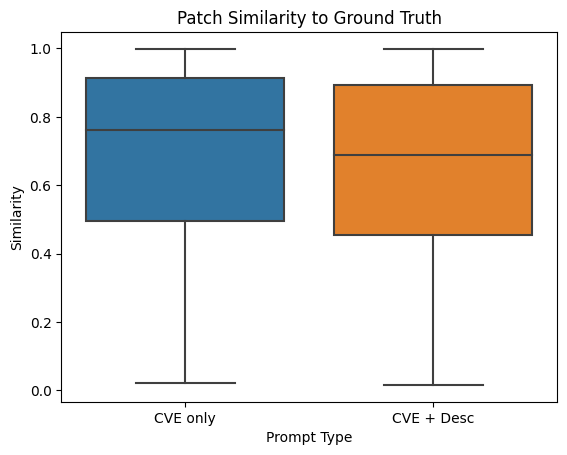

In [119]:
## Bar chart comparing prompt variants
sns.boxplot(x="prompt_type", y="similarity", data=df_plot)
plt.title("Patch Similarity to Ground Truth")
plt.ylabel("Similarity")
plt.xlabel("Prompt Type")
plt.show()

C:\Users\Sruthi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Sruthi\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


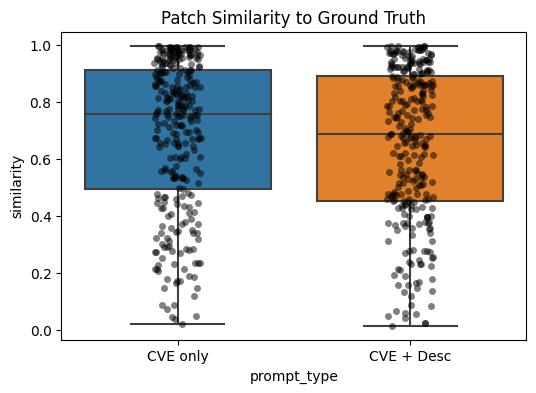

In [120]:
plt.figure(figsize=(6,4))
sns.boxplot(x="prompt_type", y="similarity", data=df_plot)
sns.stripplot(x="prompt_type", y="similarity", data=df_plot, color="black", alpha=0.5)
plt.title("Patch Similarity to Ground Truth")
plt.show()